# Initialize data variables #


In [1]:
#Load imports
%matplotlib
import matplotlib.pyplot as plt 
import matplotlib
from matplotlib import colors
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm import tqdm
import numpy as np
from astropy.io import fits
from tabulate import tabulate
import pandas

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
#Read position data#
import json
with open('APOGEE3DStarPosition.json') as file:
    AStarPositionXYZ = np.array(json.load(file))
    print(AStarPositionXYZ[2, :10])

with open('Galah3DStarPosition.json') as file:
    GStarPositionXYZ = np.array(json.load(file))

[ 0.68443777 -2.20565441 -0.03906326 -0.03906326 -8.56630669 -0.04106607
 -0.31740544 -0.46746722  0.19708223 -0.18487424]


In [3]:
#Load APOGEE clean data

with fits.open("Data/allStar-dr17-synspec_rev1.fits") as HUD:    
    data = HUD[1].data
    arrayDefs = HUD[3].data

def GoodIndices(array : np.ndarray, fieldList):
    goodIndices = np.full(len(array), True)
    for field in fieldList:
        goodIndices = goodIndices & ~np.isnan(array[field])
    return goodIndices

APOGEEGoodIndices = GoodIndices(data, ('M_H','GAIAEDR3_R_MED_GEO'))
cleanData = data[APOGEEGoodIndices]

print(len(data))
print(len(cleanData))



733901
638591


In [4]:
#Load GALAH Data
with fits.open('Data/galah_dr4_allstar_240705.fits') as hdul:
    Galah = hdul[1].data
    print(hdul[1].header)
print(len(Galah))
print(np.isfinite(Galah['age']).sum())
#Get rid of data with bad flags
GalahgoodIndices = Galah['flag_sp'] == 0 
Galah = Galah[GalahgoodIndices]
print(len(Galah))
GalahgoodIndices = Galah['snr_px_ccd3'] > 30
Galah = Galah[GalahgoodIndices]
print(len(Galah))


XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  826 / length of dimension 1                          NAXIS2  =               917588 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                  184 / number of table fields                         EXTNAME = 'Joined  '                                                            TCOMM1  = 'GALAH identifier'                                                    TUCD1   = 'meta.id '                                                            TCOMM2  = '2MASS identifier'                                                    TUCD2   = 'meta.id.cross'               

In [5]:
#Load APOGEE ages
with fits.open('Data/APOGEE_DistMass-DR17_v1.6.1.fits') as hdul:
    distMass = hdul[1].data # age is in yr
with fits.open('Data/apogee_astroNN-DR17.fits') as hdul:
    astroNN = hdul[1].data #Age is in Gyr

distMassAgeMO = distMass['AGE_COR_MO'] / 1e9 #This uses one of three models. Should compare. Maybe average them?. Dividing to make Gyr.
distMassAgeSS = distMass['AGE_COR_SS'] / 1e9
distMassAgeTW = distMass['AGE_COR_TW'] / 1e9

nnAge = astroNN['age_lowess_correct'] 

distMassAgeSS = distMassAgeSS[APOGEEGoodIndices]
distMassAgeMO = distMassAgeMO[APOGEEGoodIndices]
distMassAgeTW = distMassAgeTW[APOGEEGoodIndices]

nnAge = nnAge[APOGEEGoodIndices]
nnAccuracy = astroNN['age_total_error'][APOGEEGoodIndices]

distMassAccuracy = distMass['AGE_ERR'][APOGEEGoodIndices]


print(np.isfinite(distMassAgeSS).sum())
print(np.isfinite(nnAge).sum())

387007
624009


In [6]:
#Keep top 70% most accurate ages for AstroNN
KeepPercent = 0.70

dtype = [('accuracy', float), ('index', int)]
values = []
for i in range(len(nnAccuracy)):
    if np.isfinite(nnAge[i]):
        
        values.append((nnAccuracy[i],i))
    else:
        values.append((np.inf,i))

nnAgeAccuracyMask = np.full(nnAge.shape, False)

nnAccuracyAndIndex = np.array(values, dtype=dtype)

sortedNNAccuracy = np.sort(nnAccuracyAndIndex, order='accuracy')
print(sortedNNAccuracy)

numberOfFinte = np.isfinite(sortedNNAccuracy['accuracy']).sum()
for i in range(numberOfFinte):
    if i / numberOfFinte > KeepPercent:
        break
    nnAgeAccuracyMask[sortedNNAccuracy[i]['index']] = True

sum = np.where(np.logical_and(nnAgeAccuracyMask == True, np.isfinite(nnAge)), 1, 0).sum()
print(sum)
print(np.isfinite(nnAge[nnAgeAccuracyMask]).sum())
print(f"max uncertainty:{np.max(nnAge[nnAgeAccuracyMask])}")
print(f"mean uncertainty:{np.mean(nnAge[nnAgeAccuracyMask])}")
print(f"median uncertainty:{np.median(nnAge[nnAgeAccuracyMask])}")

[(0.10216751, 560499) (0.12347235, 529214) (0.13049005, 454721) ...
 (       inf, 638409) (       inf, 638450) (       inf, 638494)]
436807
436807
max uncertainty:15.534344383888932
mean uncertainty:5.993420281470836
median uncertainty:5.867359832495819


In [7]:
#Keep top 80% most accurate ages for DistMass
KeepPercent = 0.80
dtype = [('accuracy', float), ('index', int)]
values = []

for i in range(len(distMassAccuracy)):
    if np.isfinite(distMassAgeSS[i]):
        values.append((10**distMassAccuracy[i][0],i)) 
    else:
        values.append((np.inf,i))

distMassAccuracyMask = np.full(len(distMassAccuracy), False)

distMassAccuracyAndIndex = np.array(values, dtype=dtype)

sortedDMAccuracy = np.sort(distMassAccuracyAndIndex, order='accuracy')
print(sortedDMAccuracy[1:10])

numberOfFinte = np.isfinite(sortedDMAccuracy['accuracy']).sum()
for i in range(numberOfFinte):
    if i / numberOfFinte > KeepPercent:
        break
    distMassAccuracyMask[sortedDMAccuracy[i]['index']] = True

print(distMassAccuracyMask.shape)
print(distMassAccuracyMask.sum())
sum = np.where(np.logical_and(distMassAccuracyMask == True, np.isfinite(distMassAgeSS)), 1, 0).sum()
print(sum)
print(f"max uncertainty:{np.max(distMassAccuracy[distMassAccuracyMask])}")
print(f"mean uncertainty:{np.mean(distMassAccuracy[distMassAccuracyMask])}")
print(f"median uncertainty:{np.median(distMassAccuracy[distMassAccuracyMask])}")

[(5.01187234e-11, 237272) (5.01187234e-11, 274130)
 (5.01187234e-11, 284066) (5.01187234e-11, 493124)
 (5.01187234e-11, 604576) (5.01187234e-11,  39179)
 (5.01187234e-11,  60240) (5.01187234e-11,  60888)
 (5.01187234e-11,  60889)]
(638591,)
309606
309606
max uncertainty:0.159795067768723
mean uncertainty:-0.22777690034198178
median uncertainty:-0.11048695013728249


In [8]:
AccuracyMaskNoOverlap= np.logical_xor(nnAgeAccuracyMask, distMassAccuracyMask)
print(f"no overlap :{AccuracyMaskNoOverlap.sum()}")
AccuracyMaskOverlap = np.logical_and(nnAgeAccuracyMask, distMassAccuracyMask)
print(f"overlap :{AccuracyMaskOverlap.sum()}")

CombinedAge = np.full(nnAge.shape, np.nan)
CombinedAge = np.where(np.logical_and(AccuracyMaskNoOverlap, nnAgeAccuracyMask), nnAge, CombinedAge)
print(np.isfinite(CombinedAge).sum())
CombinedAge = np.where(np.logical_and(AccuracyMaskNoOverlap, distMassAccuracyMask), distMassAgeSS, CombinedAge)
print(np.isfinite(CombinedAge).sum())
CombinedAge = np.where(AccuracyMaskOverlap, distMassAgeSS, CombinedAge)
print(np.isfinite(CombinedAge).sum())
CombinedAgeAccuracyMask = np.isfinite(CombinedAge)

#Ok I'm not sure that mixing these age datasets is really working. Let's just go to AstroNN
CombinedAge = np.where(nnAgeAccuracyMask, nnAge, np.nan)
CombinedAgeAccuracyMask = np.isfinite(CombinedAge)
print(CombinedAgeAccuracyMask.sum())

no overlap :384923
overlap :180745
256062
384923
565668
436807


In [9]:
#Load coordinate systems
#Define frames of reference:
#Excellent, it seems that astropy has modules we can use for galactocentric coordinates!
from astropy import constants, coordinates

coordinates.galactocentric_frame_defaults.set('latest')

galEarthCen = coordinates.Galactic()

galCen = coordinates.Galactocentric()

#IMPORTANT!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
print(galCen.frame_attribute_references)

{'galcen_coord': 'https://ui.adsabs.harvard.edu/abs/2004ApJ...616..872R', 'galcen_distance': 'https://ui.adsabs.harvard.edu/abs/2018A%26A...615L..15G', 'galcen_v_sun': ['https://ui.adsabs.harvard.edu/abs/2018RNAAS...2..210D', 'https://ui.adsabs.harvard.edu/abs/2018A%26A...615L..15G', 'https://ui.adsabs.harvard.edu/abs/2004ApJ...616..872R'], 'z_sun': 'https://ui.adsabs.harvard.edu/abs/2019MNRAS.482.1417B', 'roll': None}


In [10]:
ElemSymbols = arrayDefs['ELEM_SYMBOL'][0]
ElemSymbols

chararray(['C', 'CI', 'N', 'O', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'K',
           'Ca', 'Ti', 'TiII', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu',
           'Ge', 'Rb', 'Ce', 'Nd', 'Yb', 'C13'], dtype='<U20')

In [11]:
def GetTFMaskFromBitMask(listOfBitNumbers, flagArray):
    maskList = []
    for bit in listOfBitNumbers:
        maskList.append(np.where(get_bit(flagArray, bit), False, True)) #False where the bit is true, thus get rid of these indices
    return np.logical_and.reduce(maskList)

def get_bit(value, n):
    return ((value >> n & 1) != 0)

mask = GetTFMaskFromBitMask((3, 4, 5, 6, 11), cleanData['ASPCAPFLAG'])
print(mask)
sum = np.where(mask == True, 1, 0).sum()
print(sum)

[ True False  True ...  True  True False]
497321


In [12]:
def ScrubNANs(arrays : (np.ndarray)):

    allGoodIndicesLists = []
    for arr in arrays:
        goodIndices = np.where(np.isnan(arr), False, True)
        print(goodIndices)
        allGoodIndicesLists.append(goodIndices)
    goodIndices = np.logical_and.reduce(allGoodIndicesLists)

    print(goodIndices)

    newList = []
    for arr in arrays:
        newList.append(arr[goodIndices])
    
    newarray = tuple(newList)

    return newarray

ScrubNANs( (np.array((1,np.nan,3,4,np.nan,5,6)), np.array((1,2,np.nan,4,np.nan,5,6))) )

[ True False  True  True False  True  True]
[ True  True False  True False  True  True]
[ True False False  True False  True  True]


(array([1., 4., 5., 6.]), array([1., 4., 5., 6.]))

In [13]:
ElemsToTest = {
    'C' : ('C_FE', 'c_fe', 6),
    'N' : ('N_FE', 'n_fe', 7),
    'O' : ('O_FE', 'o_fe', 8),
    'Na' : ('Na_FE', 'na_fe', 11),
    'Al' : ('Al_FE', 'al_fe', 13),
    'S' : ('S_FE', None, 16),
    'K' : ('K_FE', 'k_fe', 19),
    'Mg' : ('MG_FE', 'mg_fe', 12),
    'Si' : ('SI_FE', 'si_fe', 14),
    'Ca' : ('CA_FE', 'ca_fe', 20),
    'Ti' : ('TI_FE', 'ti_fe', 22),
    'V' : ('V_FE', 'v_fe', 23),
    'Cr' : ('CR_FE', 'cr_fe', 24),
    'Mn' : ('MN_FE', 'mn_fe', 25),
    'Co' : ('CO_FE', 'co_fe', 27),
    'Ni' : ('Ni_FE', 'ni_fe', 28),
    'Cu' : ('CU_FE', 'cu_fe', 29),
    'Zn' : (None, 'zn_fe', 30),
    'Rb' : (None, 'rb_fe', 37),
    'Sr' : (None, 'sr_fe', 38),
    'Y' : (None, 'y_fe', 39),
    'Zr' : (None, 'zr_fe', 40),
    'Mo' : (None, 'mo_fe', 42),
    'Ba' : (None, 'ba_fe', 56),
    'La' : (None, 'la_fe', 57),
    'Ce' : ('CE_FE', 'ce_fe', 58),
    'Nd' : (None, 'nd_fe', 60),
    'Eu' : (None, 'eu_fe', 63),
    'Sm' : (None, 'sm_fe', 62),
    'Ru' : (None, 'ru_fe', 44)



}

In [14]:
#Bit masks for APOGEE:
# - M_H_Warn : 3
# - ALPHA_M_WARN : 4
# - C_M_WARN: 5
# - N_M_WARN : 6
# - SN_WARN: 11

#Not using but shoul have: 8 : chi ^2 warning

mask = GetTFMaskFromBitMask((3, 4, 5, 6, 11) ,cleanData['ASPCAPFLAG']) & np.where(nnAge < 14, True, False)
GMask = np.where(np.logical_and(Galah['age'] < 14, np.isfinite(Galah['age'])), True, False)

print(mask)
sum = np.where(mask == True, 1, 0).sum()
print(sum)


UnifiedAPOGEEMask = np.logical_and(mask, CombinedAgeAccuracyMask)

print(f"Gmask sum:{GMask.sum()}")
print(f"Apogee Stars: {UnifiedAPOGEEMask.sum()}")
print(f"total Stars : {GMask.sum() + UnifiedAPOGEEMask.sum()}")


[ True False  True ...  True  True False]
488630
Gmask sum:625213
Apogee Stars: 343862
total Stars : 969075


In [ ]:
# First, lets just double check how many stars we have
print(len(data['TARGET_ID']))
#733,901

## Finding Age Estimates to Cross-Ref ##


OK, we've now found one data source for ages using AstroNN 

https://data.sdss.org/datamodel/files/APOGEE_ASTRONN/apogee_astronn.html

" "This value-added catalog contains the results from applying the astroNN deep-learning code to APOGEE spectra to determine stellar parameters, individual stellar abundances (Leung & Bovy 2019a), distances (Leung & Bovy 2019b), and ages (Mackereth et al. 2019). In addition, properties of the orbits in the Milky Way (and their uncertainties) for all stars are computed using the fast method of Mackereth & Bovy (2018) assuming the MWPotential2014 gravitational potential from Bovy (2015). The data file is row-matched to the allStar for easy access to the regular catalog data for each object."

In [ ]:
with fits.open('apogee_astroNN-DR17.fits') as hdul:
    astroNN = hdul[1].data #Age is in Gyr

Another data soucre: 

https://data.sdss.org/datamodel/files/APOGEE_DISTMASS/APOGEE_DistMass.html

"This Value-added catalog contains the absolute magnitudes, distances, masses for dr17 stars. These values were estimated using a small machine learning network. File also contains the stellar parameters used by the neural network. Select giant stars also have a predicted age calculated using the estimated mass."

(See Section 6 in https://iopscience.iop.org/article/10.3847/1538-3881/ad12a6/pdf)


In [ ]:
with fits.open('APOGEE_DistMass-DR17_v1.6.1.fits') as hdul:
    distMass = hdul[1].data # age is in yr

Ok, let's do a comparison of the age estimates:

nnAge:2.3148725522321163
distMassAge:2.8189290846614514
394308
702734


117576


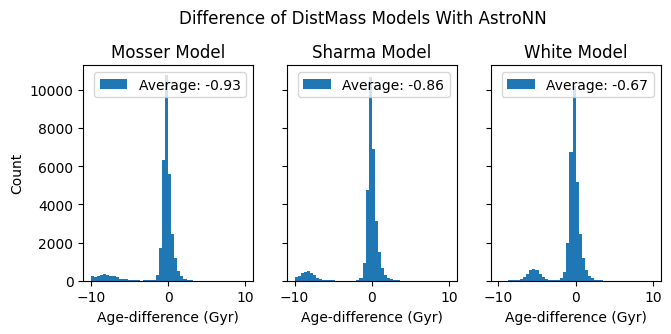

In [51]:
# Scatter plot with age estimates for each star between the two data sets
combinedAPOGEEAgeMask = np.logical_and.reduce((mask, nnAgeAccuracyMask, distMassAccuracyMask))
print(combinedAPOGEEAgeMask.sum())

tempmask = combinedAPOGEEAgeMask

fig ,(ax1,ax2,ax3) = plt.subplots(1,3, sharey=True, figsize=(7.45,2.8))

hist = ax1.hist ((nnAge - distMassAgeMO)[tempmask], bins=50, range=(-10,10), label=f'Average: {round(np.nanmean((nnAge - distMassAgeMO)[tempmask]), 2)}')
ax1.set_title('Mosser Model')
ax1.legend()

hist2 = ax2.hist((nnAge - distMassAgeSS)[tempmask], bins=50, range=(-10,10) ,label=f'Average: {round(np.nanmean((nnAge - distMassAgeSS)[tempmask]), 2)}')
ax2.set_title('Sharma Model')
ax2.legend()

hist3 = ax3.hist((nnAge - distMassAgeTW)[tempmask], bins=50,range=(-10,10), label=f'Average: {round(np.nanmean((nnAge - distMassAgeTW)[tempmask]), 2)}')
ax3.set_title('White Model')
ax3.legend()

fig.suptitle('Difference of DistMass Models With AstroNN',y=1.08)

ax1.set_ylabel("Count")
ax1.autoscale()

for ax in (ax1,ax2,ax3):

    ax.set_xlabel("Age-difference (Gyr)")


plt.show()

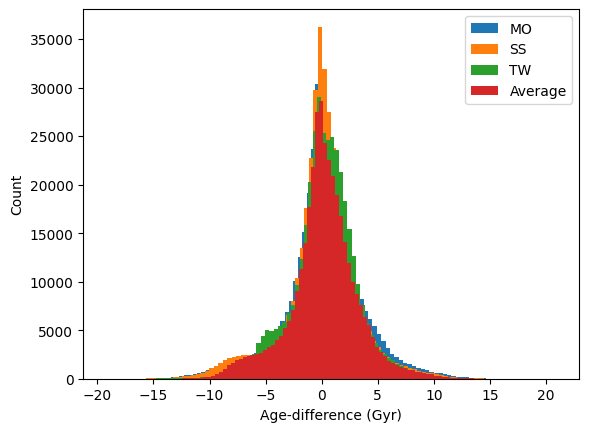

In [14]:
fig , ax= plt.subplots()

hist = ax.hist (nnAge - distMassAgeMO, bins=100, label='MO')

hist2 = ax.hist(nnAge - distMassAgeSS, bins=100, label='SS')

hist3 = ax.hist(nnAge - distMassAgeTW, bins=100, label='TW')

distMassAvg = (distMassAgeMO + distMassAgeSS + distMassAgeTW) / 3

hist4 = ax.hist(nnAge - distMassAvg, bins = 100, label='Average')

ax.legend()


ax.set_ylabel("Count")
ax.set_xlabel("Age-difference (Gyr)")

plt.show()

In [ ]:
def ScrubNAN(array : np.ndarray):
    badIndices = np.isnan(array)
    goodIndices = ~badIndices
    return array[goodIndices]

In [ ]:
#It appears that the average has the least divergence from astroNN. Let's try to check that 
AvgErrorMO = np.average(ScrubNAN(nnAge - distMassAgeMO))
AvgErrorSS = np.average(ScrubNAN(nnAge - distMassAgeSS))
AvgErrorTW = np.average(ScrubNAN(nnAge - distMassAgeTW))
AvgErrorAvg = np.average(ScrubNAN(nnAge - distMassAvg))



print(f'MO:{AvgErrorMO}')
print(f'SS:{AvgErrorSS}')
print(f'TW:{AvgErrorTW}')
print(f'AVG:{AvgErrorAvg}')

## Apparently, TW is best??

In [ ]:
#Really quick, let's just check how many entries aren't Nan'd
print(len(ScrubNAN(nnAge)))
print(len(ScrubNAN(distMassAgeSS)))
#Ok, pretty good!

Alright, these age estimates seem like a good start. Let's start getting the other major pieces into place.

## Resolving Galactic Position and Drawing Map ## 
https://milkyway-plot.readthedocs.io/en/stable/ This project is an option (was used in pro papers) but I'd like to do it myself 



In [ ]:
#Define frames of reference:
#Excellent, it seems that astropy has modules we can use for galactocentric coordinates!
from astropy import constants, coordinates

coordinates.galactocentric_frame_defaults.set('latest')

galEarthCen = coordinates.Galactic()

galCen = coordinates.Galactocentric()

#IMPORTANT!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
print(galCen.frame_attribute_references)


In [ ]:
def GoodIndices(array : np.ndarray, fieldList):
    goodIndices = np.full(len(array), True)
    for field in fieldList:
        goodIndices = goodIndices & ~np.isnan(array[field])
    return goodIndices

cleanData = data[GoodIndices(data, ('M_H','GAIAEDR3_R_MED_GEO'))]
print(len(cleanData))

In [ ]:
#Alright let's get star positions#
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm import tqdm
#Let's just use the first 100 stars with no NANs

AstarXPosition = []
AstarYPosition = []
AstarZPosition = []

for star in tqdm(cleanData):
    dist = coordinates.Distance(star['GAIAEDR3_R_MED_GEO'], unit=u.pc).to(u.kpc)
    coord = SkyCoord(
    star['GLON'] * u.degree,
    star['GLAT'] * u.degree,
    distance=dist,
    frame="galactic",
    )
    galactocentricCoord = coord.transform_to(galCen)

    AstarXPosition.append(galactocentricCoord.cartesian.x / u.kpc)
    AstarYPosition.append(galactocentricCoord.cartesian.y / u.kpc)
    AstarZPosition.append(galactocentricCoord.cartesian.z / u.kpc)
    #xyz = np.array( (galactocentricCoord.cartesian.x / u.pc,galactocentricCoord.cartesian.y / u.pc,galactocentricCoord.cartesian.z / u.pc))
    #starXYZPositions.append(xyz)

In [ ]:
#Let's visualize the positions in a hist2d#


fig, ax = plt.subplots()

#axPolar = fig.add_axes(ax.get_position(),polar=True, frameon=False)



hist = ax.hist2d(AstarXPosition, AstarYPosition, bins=250, range=[[-25,25],[-25,25]], norm=colors.LogNorm())
ax.set_xlabel("$x$ [kpc]")
ax.set_ylabel("$y$ [kpc]")
ax.set_title("Positions")
fig.colorbar( hist[3], ax = ax, label='counts')

for r in range(10):
    ax.add_artist(plt.Circle([0,0], r*3,fc='none', ec='blue'))

ax.text(-galCen.galcen_distance /u.kpc, 0, r"$\odot$", fontsize=20, horizontalalignment='center', verticalalignment='center')
ax.text(0, 0, r"$\star$", fontsize=30,horizontalalignment='center', verticalalignment='center')


plt.show(True)



In [ ]:
#Let's try a 3D scatter
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_xlim3d(-20, 10)
ax.set_ylim3d(15,-20)

ax.scatter(AstarXPosition,AstarYPosition,AstarZPosition, c=cleanData['M_H'], cmap='inferno')

plt.show()

# Comparing and combining GALAH and DR17 data #

In [56]:
#Check the overlap between Gahlah and DR17

intersect = np.intersect1d(cleanData['GAIAEDR3_SOURCE_ID'], Galah['gaiadr3_source_id'])
print(f'Number of same stars = {len(intersect)} = {len(intersect) / (len(Galah) + len(cleanData)) * 100}%')

Number of same stars = 40513 = 3.18870443190011%


In [ ]:
#Alright let's get star positions for both catalogs#
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm import tqdm
import json

AstarXPosition = []
AstarYPosition = []
AstarZPosition = []

for star in tqdm(cleanData):
    dist = coordinates.Distance(star['GAIAEDR3_R_MED_GEO'], unit=u.pc).to(u.kpc)
    coord = SkyCoord(
    star['GLON'] * u.degree,
    star['GLAT'] * u.degree,
    distance=dist,
    frame="galactic",
    )
    galactocentricCoord = coord.transform_to(galCen)

    AstarXPosition.append(float(galactocentricCoord.cartesian.x / u.kpc))
    AstarYPosition.append(float(galactocentricCoord.cartesian.y / u.kpc))
    AstarZPosition.append(float(galactocentricCoord.cartesian.z / u.kpc))
    #xyz = np.array( (galactocentricCoord.cartesian.x / u.pc,galactocentricCoord.cartesian.y / u.pc,galactocentricCoord.cartesian.z / u.pc))
    #starXYZPositions.append(xyz)

AStarPositionXYZ = [AstarXPosition, AstarYPosition, AstarZPosition]

with open('APOGEE3DStarPosition.json', 'w', encoding='utf-8') as file:
    json.dump(AStarPositionXYZ, file, ensure_ascii=False, indent=4)

GstarXPosition = []
GstarYPosition = []
GstarZPosition = []

for star in tqdm(Galah):
    dist = coordinates.Distance(star['r_med'], unit=u.pc).to(u.kpc)
    coord = SkyCoord(
    star['ra'] * u.degree,
    star['dec'] * u.degree,
    distance=dist,
    frame="icrs",
    )
    galactocentricCoord = coord.transform_to(galCen)

    GstarXPosition.append(float(galactocentricCoord.cartesian.x / u.kpc))
    GstarYPosition.append(float(galactocentricCoord.cartesian.y / u.kpc))
    GstarZPosition.append(float(galactocentricCoord.cartesian.z / u.kpc))

GStarPositionXYZ = [GstarXPosition, GstarYPosition, GstarZPosition]

with open('Galah3DStarPosition.json', 'w', encoding='utf-8') as file:
    json.dump(GStarPositionXYZ, file, ensure_ascii=False, indent=4)

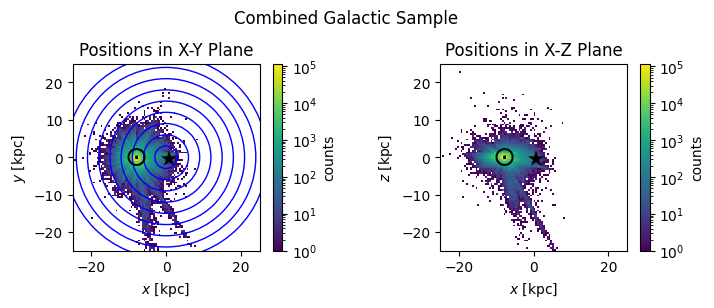

In [109]:
#OK, let's get plotting!
fig, (ax, ax2) = plt.subplots(ncols=2, figsize=(7.5,3))

#axPolar = fig.add_axes(ax.get_position(),polar=True, frameon=False)

ax.set_aspect('equal')
ax2.set_aspect('equal')


hist = ax.hist2d(np.concat((np.array(AStarPositionXYZ[0])[UnifiedAPOGEEMask], GStarPositionXYZ[0][GMask])), np.concat((np.array(AStarPositionXYZ[1])[UnifiedAPOGEEMask], GStarPositionXYZ[1][GMask])), bins=100, range=[[-25,25],[-25,25]], norm=colors.LogNorm())
ax.set_xlabel("$x$ [kpc]")
ax.set_ylabel("$y$ [kpc]")
ax.set_title("Positions in X-Y Plane")
fig.colorbar( hist[3], ax = ax, label='counts')

AddGalaxyReference(ax)

hist = ax2.hist2d(np.concat((np.array(AStarPositionXYZ[0])[UnifiedAPOGEEMask], GStarPositionXYZ[0][GMask])), np.concat((np.array(AStarPositionXYZ[2])[UnifiedAPOGEEMask], GStarPositionXYZ[2][GMask])), bins=100, range=[[-25,25],[-25,25]], norm=colors.LogNorm())
ax2.set_xlabel("$x$ [kpc]")
ax2.set_ylabel("$z$ [kpc]")
ax2.set_title("Positions in X-Z Plane")
fig.colorbar( hist[3], ax = ax2, label='counts')

def AddXZGalaxyReference(ax):
    ax.text(-galCen.galcen_distance /u.kpc, galCen.z_sun / u.kpc, r"$\odot$", fontsize=20, horizontalalignment='center', verticalalignment='center')
    ax.text(0, 0, r"$\star$", fontsize=30,horizontalalignment='center', verticalalignment='center')

AddXZGalaxyReference(ax2)

def AddGalaxyReference(ax):
    for r in range(10):
        ax.add_artist(plt.Circle([0,0], r*3,fc='none', ec='blue'))

    ax.text(-galCen.galcen_distance /u.kpc, 0, r"$\odot$", fontsize=20, horizontalalignment='center', verticalalignment='center')
    ax.text(0, 0, r"$\star$", fontsize=30,horizontalalignment='center', verticalalignment='center')

fig.suptitle('Combined Galactic Sample')

fig.tight_layout()

# Analysis of Combined data #

## Figures of position vs. metallicity of diff. elements and age##

In [50]:
def PlotGalaxyWithColorData(suptitle, StarPositionsXYZ, field, Mask, quantityName, title, bins, useBinExtents=False, GalahPosition =None, GalahField = None):
    # Do X-Y Plane --------------------------------------------------------------------------------------------------------
    distrange=[[-25,25],[-25,25], [-25, 25]]

    # Find line with (min, 0*bins), (max, 1*bins) => y = ((x-min)/(max-min))c
    xbinf = lambda x : int(np.floor((x-distrange[0][0]) / (distrange[0][1] - distrange[0][0]) * bins))
    ybinf = lambda y : int(np.floor((y-distrange[1][0]) / (distrange[1][1] - distrange[1][0]) * bins))
    zbinf = lambda z : int(np.floor((z-distrange[2][0]) / (distrange[2][1] - distrange[2][0]) * bins))

    binArray = np.full((bins,bins,2), np.inf, dtype=np.float64)

    if type(Mask) == type(None):
        Mask = np.full(field.shape, True)

    for quantity, mask, positionX, positionY, positionZ in zip(field, Mask, StarPositionsXYZ[0],StarPositionsXYZ[1], StarPositionsXYZ[2], strict=True):

        if mask:
            xbin = xbinf(positionX)
            ybin = ybinf(positionY)
            if xbin in range(bins) and ybin in range(bins):
                if not np.isnan(quantity):
                    if binArray[ybin][xbin][0] == np.inf:
                        binArray[ybin][xbin][0] = quantity
                        binArray[ybin][xbin][1] = 1
                    else:
                        binArray[ybin][xbin][0] += quantity
                        binArray[ybin][xbin][1] += 1

    if not type(GalahPosition) == type(None):
        for quantity, positionX, positionY in zip(GalahField, GalahPosition[0],GalahPosition[1], strict=True):
            xbin = xbinf(positionX)
            ybin = ybinf(positionY)
            if xbin in range(bins) and ybin in range(bins):
                if not np.isnan(quantity):
                    if binArray[ybin][xbin][0] == np.inf:
                        binArray[ybin][xbin][0] = quantity
                        binArray[ybin][xbin][1] = 1
                    else:
                        binArray[ybin][xbin][0] += quantity
                        binArray[ybin][xbin][1] += 1

    averagedBins = np.zeros((bins,bins))

    for y in range(bins):
        for x in range(bins):
            if binArray[y][x][0] == np.inf:
                averagedBins[y][x] = np.inf
            else:
                averagedBins[y][x] = binArray[y][x][0] / binArray[y][x][1]
        
    maskedBins = np.ma.masked_where(averagedBins == np.inf, averagedBins)
    
    fig, (ax,ax2) = plt.subplots(ncols=2, figsize=(7.5,4))

    if useBinExtents: usedBinExtents = 'none'
    else : usedBinExtents = [distrange[0][0],distrange[0][1], distrange[1][0], distrange[1][1]]

    #Use min and max cutting out the top and bottom 1%
    vmin = sorted(maskedBins.compressed())[int(0.01*maskedBins.compressed().size)]
    vmax = sorted(maskedBins.compressed())[maskedBins.compressed().size - int(0.01*maskedBins.compressed().size)]
    print(f"vmin={vmin}, vmax={vmax}")

    img = ax.imshow(maskedBins, cmap='Spectral', vmin=vmin, vmax=vmax, interpolation='none',  extent=usedBinExtents, origin='lower')


    ax.set_xlabel("$x$ [kpc]")
    ax.set_ylabel("$y$ [kpc]")
    ax.set_title(f"{title} in X-Y Plane")
    fig.colorbar( img, ax = ax, label=quantityName)
    
    AddGalaxyReference(ax)

    # Do X-Z Plane --------------------------------------------------------------------------------------------------------

    binArray = np.full((bins,bins,2), np.inf, dtype=np.float64)

    if type(Mask) == type(None):
        Mask = np.full(field.shape, True)

    for quantity, mask, positionX, positionZ in zip(field, Mask, StarPositionsXYZ[0], StarPositionsXYZ[2], strict=True):
        if mask:

            xbin = xbinf(positionX)
            zbin = zbinf(positionZ)
            if xbin in range(bins) and zbin in range(bins):
                if not np.isnan(quantity):
                    if binArray[zbin][xbin][0] == np.inf:
                        binArray[zbin][xbin][0] = quantity
                        binArray[zbin][xbin][1] = 1
                    else:
                        binArray[zbin][xbin][0] += quantity
                        binArray[zbin][xbin][1] += 1

    if not type(GalahPosition) == type(None):
        for quantity, positionX, positionY, positionZ in zip(GalahField, GalahPosition[0],GalahPosition[1], GalahPosition[2], strict=True):

            xbin = xbinf(positionX)
            zbin = zbinf(positionZ)
            if xbin in range(bins) and zbin in range(bins):
                if not np.isnan(quantity):
                    if binArray[zbin][xbin][0] == np.inf:
                        binArray[zbin][xbin][0] = quantity
                        binArray[zbin][xbin][1] = 1
                    else:
                        binArray[zbin][xbin][0] += quantity
                        binArray[zbin][xbin][1] += 1

    averagedBins = np.zeros((bins,bins))

    for z in range(bins):
        for x in range(bins):
            if binArray[z][x][0] == np.inf:
                averagedBins[z][x] = np.inf
            else:
                averagedBins[z][x] = binArray[z][x][0] / binArray[z][x][1]
        
    maskedBins = np.ma.masked_where(averagedBins == np.inf, averagedBins)

    if useBinExtents: usedBinExtents = 'none'
    else : usedBinExtents = [distrange[0][0],distrange[0][1], distrange[2][0], distrange[2][1]]

    img2 = ax2.imshow(maskedBins, cmap='Spectral', vmin=vmin, vmax=vmax, interpolation='none',  extent=usedBinExtents, origin='lower')


    ax2.set_xlabel("$x$ [kpc]")
    ax2.set_ylabel("$z$ [kpc]")
    ax2.set_title(f"{title} in X-Z Plane")
    fig.colorbar( img2, ax = ax2, label=quantityName)
    
    AddXZGalaxyReference(ax2)

    fig.suptitle(suptitle)

    fig.tight_layout()

    plt.show()
    fig.savefig(f'AllGalacticMaps/{str.replace(title, '/','')}.png')

def AddGalaxyReference(ax):
    for r in range(10):
        ax.add_artist(plt.Circle([0,0], r*3,fc='none', ec='blue', alpha=0.5))

    ax.text(-galCen.galcen_distance /u.kpc, 0, r"$\odot$", fontsize=20, horizontalalignment='center', verticalalignment='center')
    ax.text(0, 0, r"$\star$", fontsize=30,horizontalalignment='center', verticalalignment='center')

def AddXZGalaxyReference(ax):
    ax.text(float(-galCen.galcen_distance /u.kpc), float(galCen.z_sun / u.kpc), r"$\odot$", fontsize=20, horizontalalignment='center', verticalalignment='center')
    ax.text(0, 0, r"$\star$", fontsize=30,horizontalalignment='center', verticalalignment='center')

#Bit masks for APOGEE:
# - M_H_Warn : 3
# - ALPHA_M_WARN : 4
# - C_M_WARN: 5
# - N_M_WARN : 6
# SN_WARN: 11

#Element Numbers for APOGEE

#PlotGalaxyWithColorData(AStarPositionXYZ, cleanData['X_H'][: , 17], GetTFMaskFromBitMask((3, 11) ,cleanData['ASPCAPFLAG']), '[Fe/H]', 'Metallicity', 100, False)
#PlotGalaxyWithColorData(GStarPositionXYZ, Galah['fe_h'], None, '[Fe/H]', 'Metallicity', 100)


497321
vmin=-0.6317600011825562, vmax=0.16224420070648193


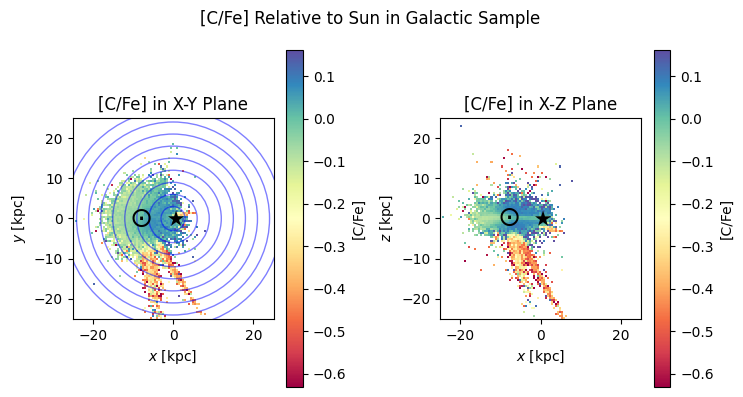

vmin=-0.08465047925710678, vmax=0.7353325188159943


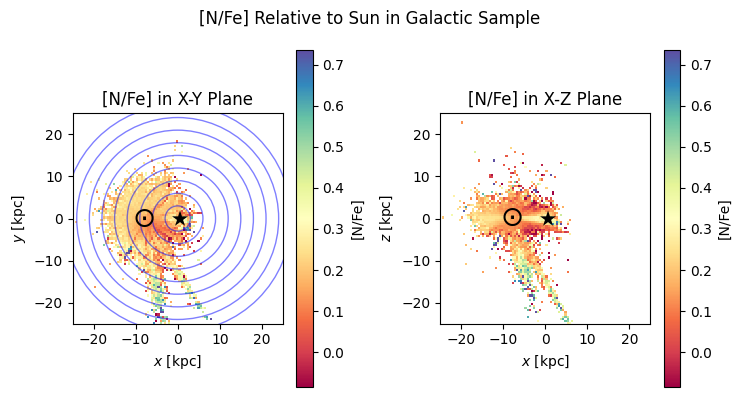

vmin=-0.06640533606211345, vmax=0.657039076089859


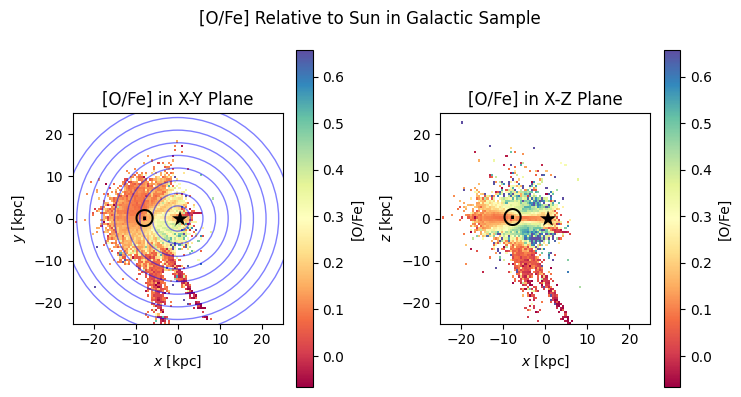

vmin=-0.564887523651123, vmax=0.38834625482559204


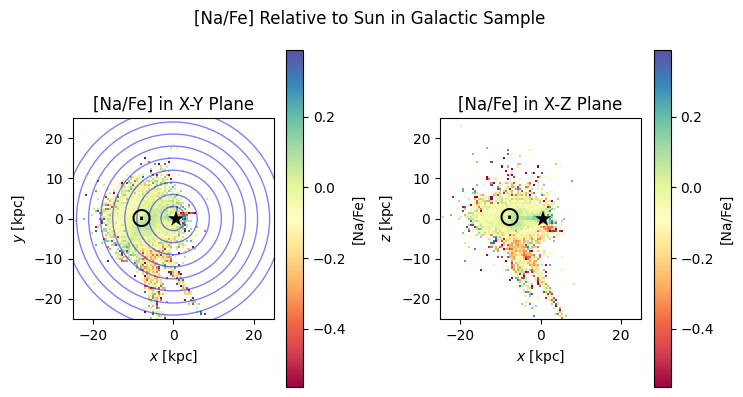

vmin=-0.5288590788841248, vmax=0.31291262805461884


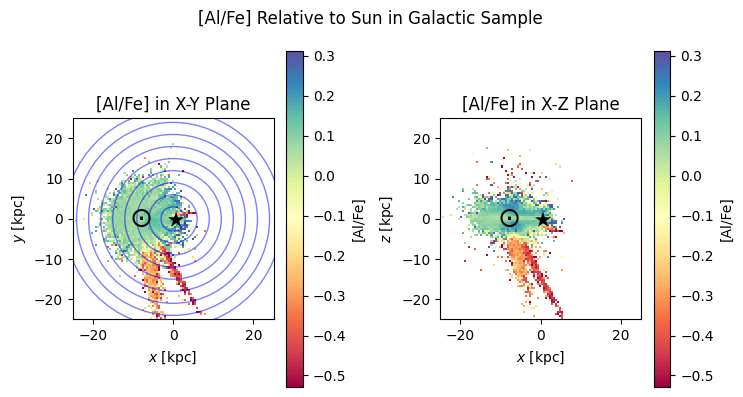

vmin=-0.28443766633669537, vmax=0.34324800968170166


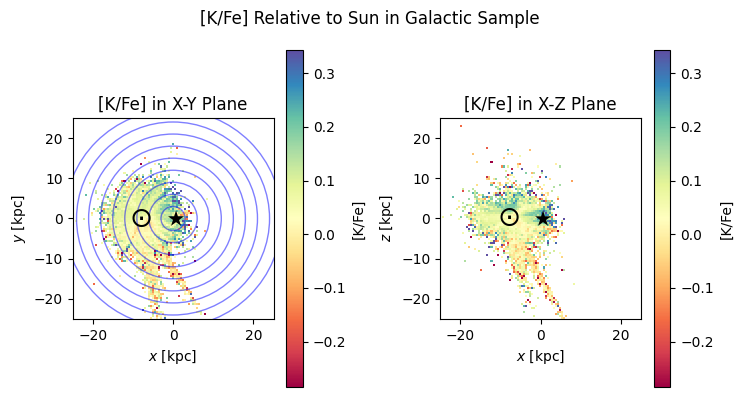

vmin=-0.1891173521677653, vmax=0.424772709608078


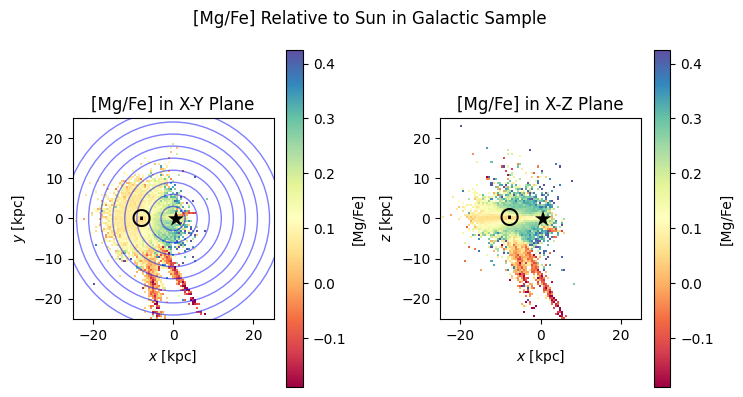

vmin=-0.12925938765207926, vmax=0.4166121184825897


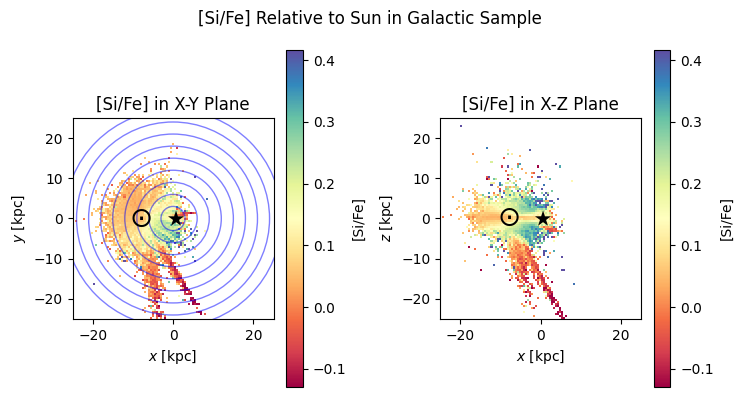

vmin=-0.04261757185061773, vmax=0.3814862370491028


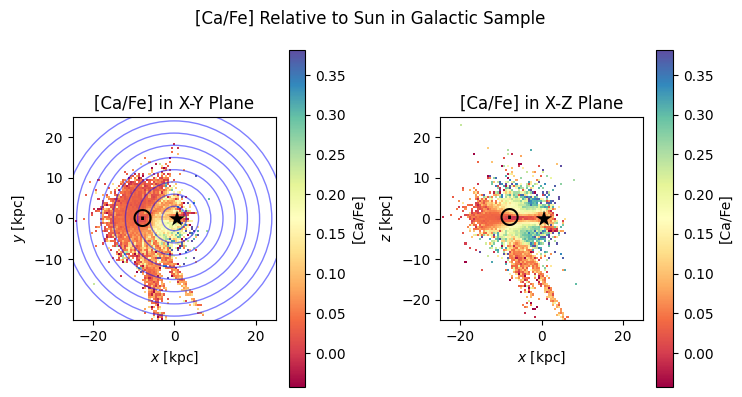

vmin=-0.27145686745643616, vmax=0.3362395465373993


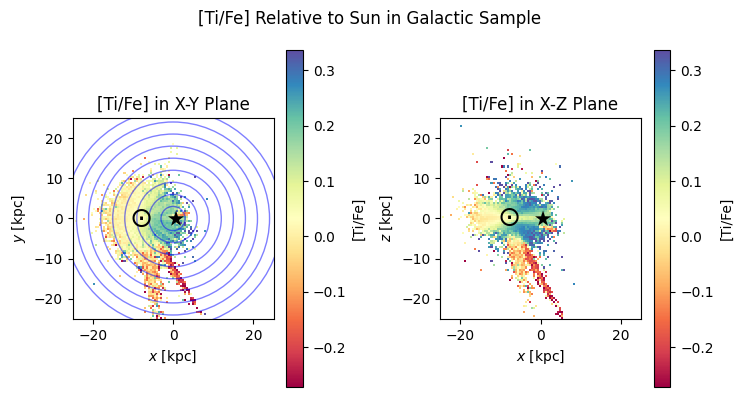

vmin=-0.6838279962539673, vmax=0.32248201966285706


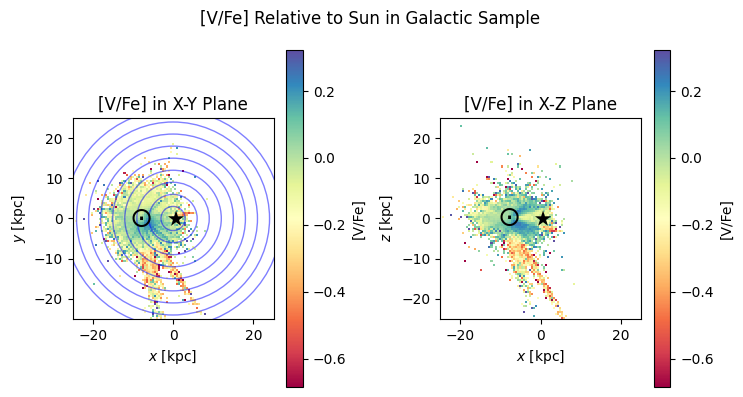

vmin=-0.43524599075317383, vmax=0.14578203856945038


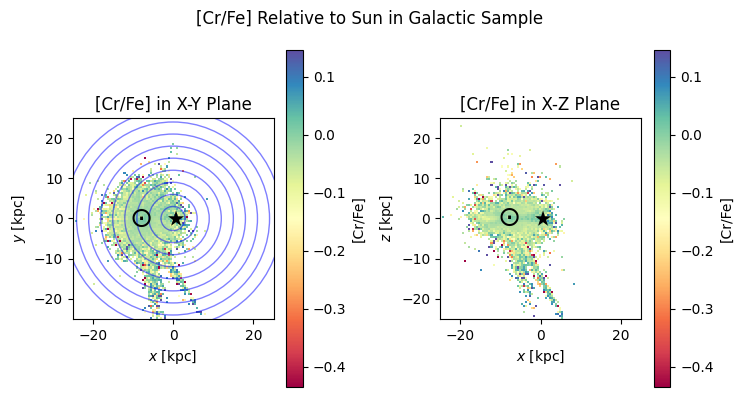

vmin=-0.3219780921936035, vmax=0.09728200733661652


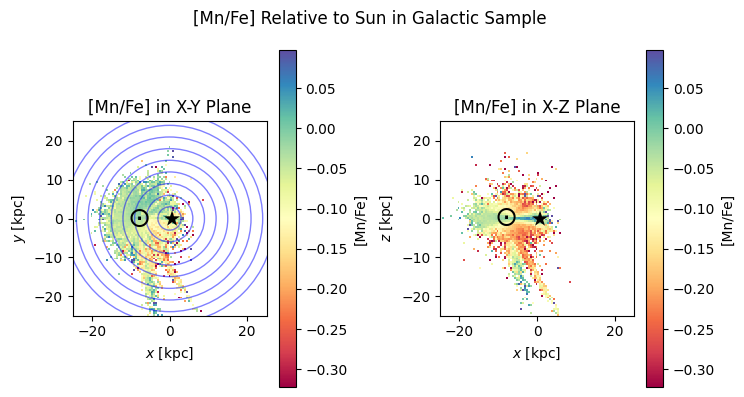

vmin=-0.37393003702163696, vmax=0.2593899965286255


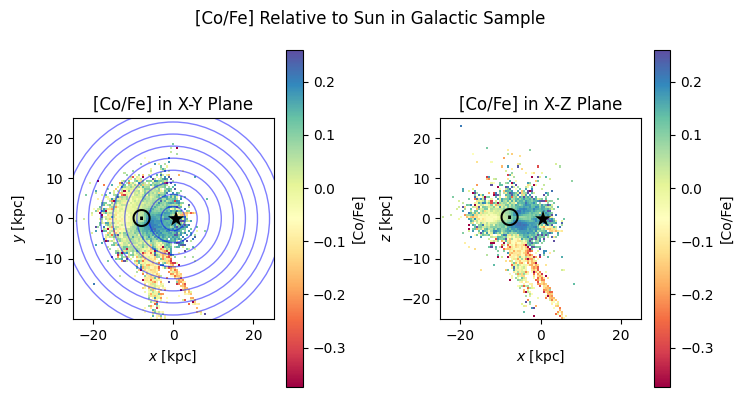

vmin=-0.17742352187633514, vmax=0.10203583041826884


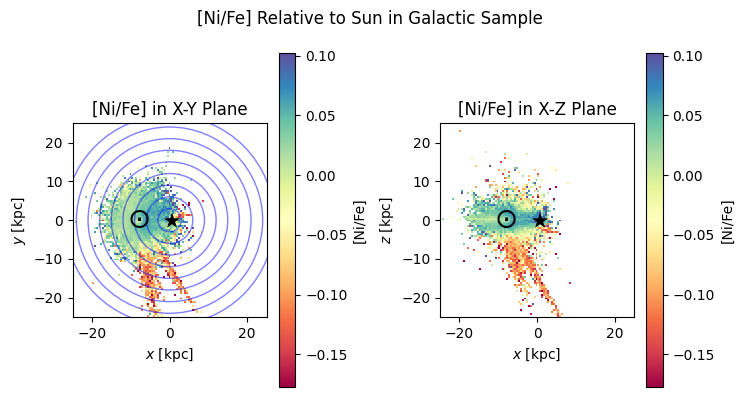

vmin=-0.4068911671638489, vmax=0.27581849694252014


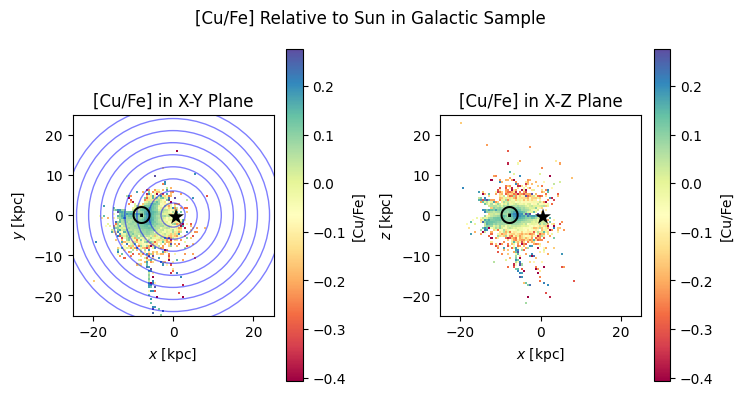

vmin=-0.34711499512195587, vmax=0.4985709935426712


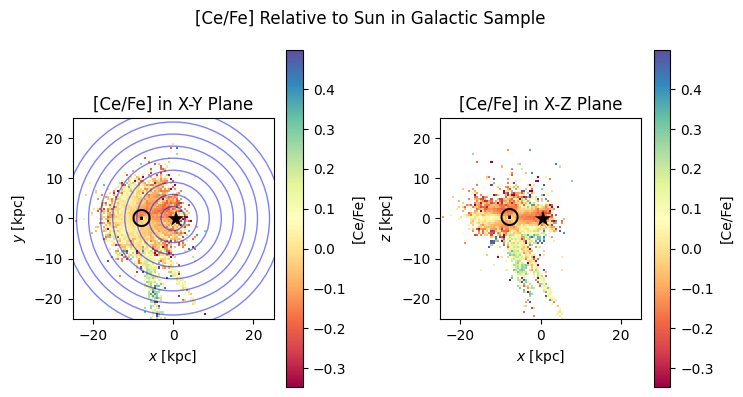

17


In [51]:
mask = GetTFMaskFromBitMask((3, 4, 5, 6, 11) ,cleanData['ASPCAPFLAG'])
print(np.where(mask == True, 1, 0).sum())
count = 0
for elemInfo, (apogeeIndex, GField, z) in zip(ElemsToTest.keys(), ElemsToTest.values()):
    if GField == None or apogeeIndex == None:
        continue
    GElemMask = np.where(Galah[f'flag_{GField}'] == 0, True, False) & GMask

    PlotGalaxyWithColorData(f'[{elemInfo}/Fe] Relative to Sun in Galactic Sample', AStarPositionXYZ, cleanData[GField], UnifiedAPOGEEMask, f'[{elemInfo}/Fe]', f'[{elemInfo}/Fe]', bins=100, useBinExtents=False, GalahPosition= GStarPositionXYZ[ :, GElemMask], GalahField=Galah[GField][GElemMask])
    count += 1
print(count)

vmin=-1.8916107416152954, vmax=0.028095006942749023


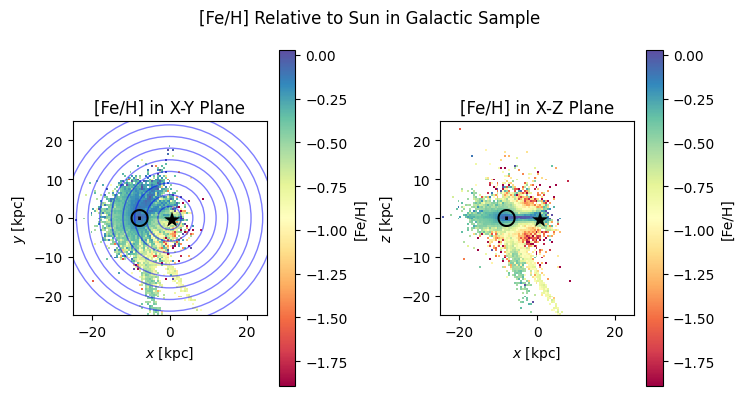

In [19]:
GElemMask = np.where(Galah['flag_fe_h'] == 0, True, False) & GMask

PlotGalaxyWithColorData(f'[Fe/H] Relative to Sun in Galactic Sample', AStarPositionXYZ, cleanData['FE_H'], UnifiedAPOGEEMask, f'[Fe/H]', f'[Fe/H]', bins=100, useBinExtents=False, GalahPosition= GStarPositionXYZ[ :, GElemMask], GalahField=Galah['fe_h'][GElemMask])


## Age investigations ##

vmin=0.3823397755622864, vmax=9.664183699571879


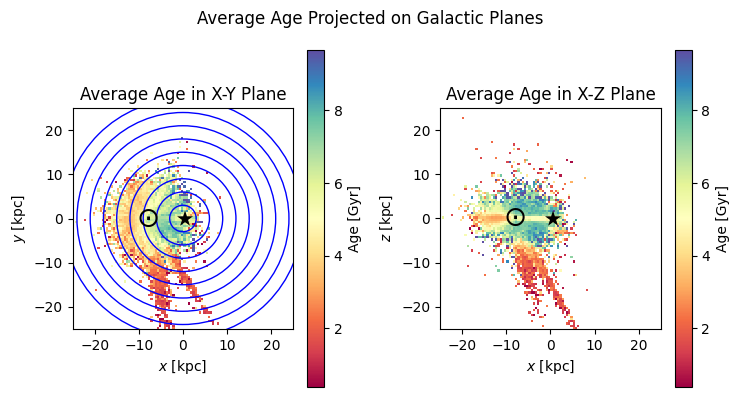

In [111]:
#Let's do a figure with average age
mask = GetTFMaskFromBitMask((3, 4, 5, 6, 11) ,cleanData['ASPCAPFLAG'])

PlotGalaxyWithColorData('Average Age Projected on Galactic Planes', np.array(AStarPositionXYZ), CombinedAge, UnifiedAPOGEEMask, 'Age [Gyr]','Average Age', 100, False, GStarPositionXYZ, Galah['age'])

In [21]:
import plotsAndLines
import importlib
importlib.reload(plotsAndLines)
from plotsAndLines import LineData
from plotsAndLines import PlotContainer

lineData = []
for elemInfo, (apogeeIndex, GField, z) in tqdm(zip(ElemsToTest.keys(), ElemsToTest.values())):
    nextInput = []
    if type(apogeeIndex) is not type(None):
        nextInput = [CombinedAge, cleanData[apogeeIndex], z, elemInfo, UnifiedAPOGEEMask]
        if np.isfinite(cleanData[apogeeIndex][UnifiedAPOGEEMask]).sum() == 0: print(f"APOGEE added nothing for {GField}")
    if type(GField) is not type(None):
        if nextInput == []:
            nextInput = (Galah['age'], Galah[GField], z, elemInfo, GMask & (Galah[f'flag_{GField}'] == 0))
        else:
            nextInput[0] = np.append(nextInput[0], Galah['age'])
            nextInput[1] = np.append(nextInput[1], Galah[GField])
            nextInput[4] = np.append(nextInput[4], GMask & (Galah[f'flag_{GField}'] == 0))

    nextLine = (LineData(nextInput[0],nextInput[1],nextInput[2],nextInput[3],nextInput[4]))
    lineData.append(nextLine)

LineData.ColorizeCField(lineData, 'Spectral')

lineDataOverH = []

for elemInfo, (apogeeIndex, GField, z) in tqdm(zip(ElemsToTest.keys(), ElemsToTest.values())):
    nextInput = []
    if type(apogeeIndex) is not type(None):
        nextInput = [CombinedAge, cleanData[apogeeIndex] + cleanData['FE_H'], z, elemInfo, UnifiedAPOGEEMask]
    if type(GField) is not type(None):
        if nextInput == []:
            nextInput = (Galah['age'], Galah[GField] + Galah['fe_h'], z, elemInfo, GMask & (Galah[f'flag_{GField}'] == 0))
        else:
            nextInput[0] = np.append(nextInput[0], Galah['age'])
            nextInput[1] = np.append(nextInput[1], Galah[GField] + Galah['fe_h'])
            nextInput[4] = np.append(nextInput[4], GMask & (Galah[f'flag_{GField}'] == 0))

    nextLine = (LineData(nextInput[0],nextInput[1],nextInput[2],nextInput[3],nextInput[4]))
    lineDataOverH.append(nextLine)

LineData.ColorizeCField(lineDataOverH, 'Spectral')

16it [00:03,  4.06it/s]

APOGEE added nothing for cu_fe


30it [00:04,  6.07it/s]
30it [00:05,  5.96it/s]


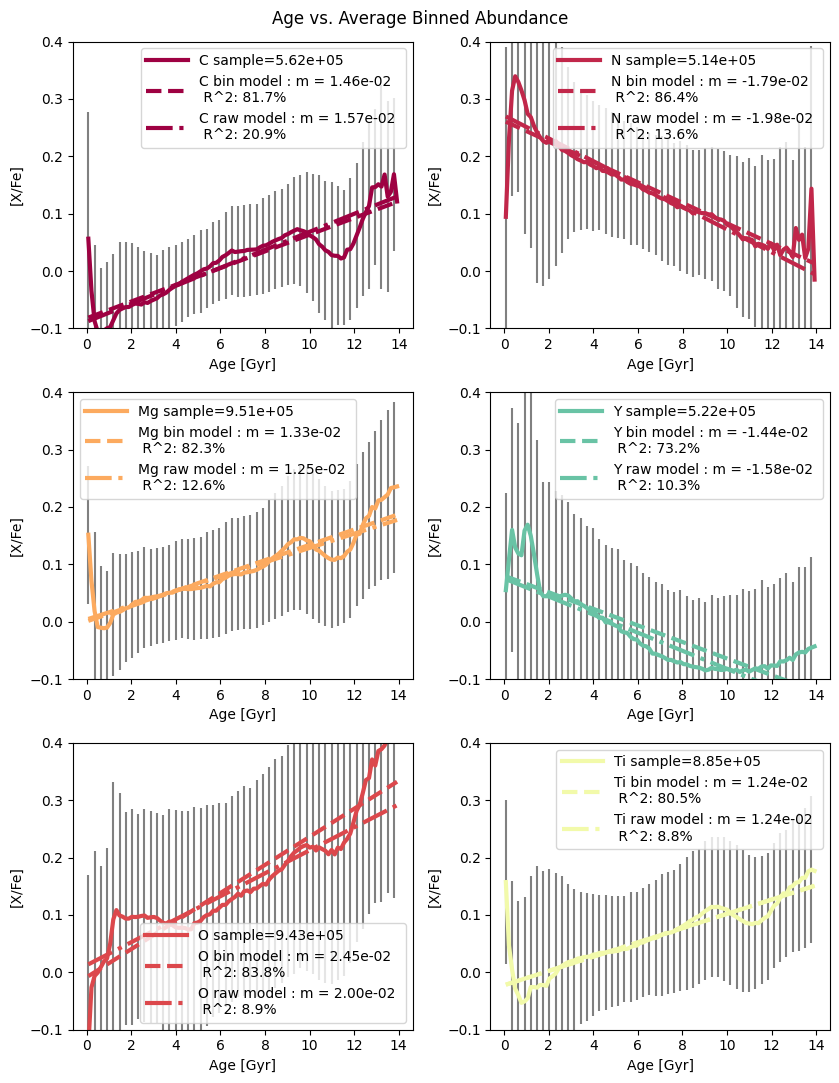

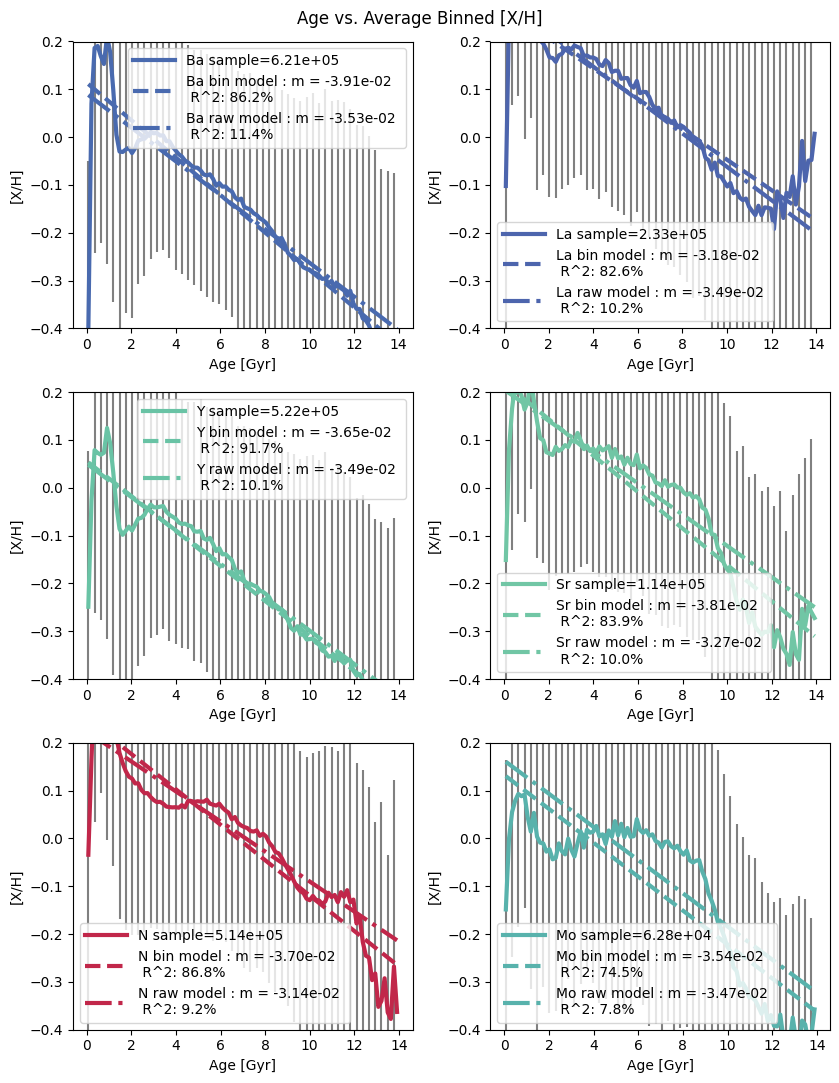

In [23]:

import plotsAndLines
import importlib
importlib.reload(plotsAndLines)
from plotsAndLines import LineData
from plotsAndLines import PlotContainer

titleAndUnits = PlotContainer.TitleAndUnitLabels('Age vs. Average Binned Abundance', 'Age [Gyr]', '[X/Fe]', yRange=(-0.1,0.4))
axesController = PlotContainer.AxesController(2,3,1)
axesPlotter = PlotContainer.AxesPlotter((PlotContainer.AxesPlotter.StdPlotFunc, PlotContainer.AxesPlotter.LinearRegressPlotFunc, PlotContainer.AxesPlotter.RawLinearRegressPlotFunc))
container = PlotContainer(axesPlotter, titleAndUnits, axesController)
lineData = LineData.Sort(lineData,'rawrsquared')
container((lineData,))

HtitleAndUnits = PlotContainer.TitleAndUnitLabels('Age vs. Average Binned [X/H]', 'Age [Gyr]', '[X/H]', yRange=(-0.4,0.2))
container.titleAndUnitObj = HtitleAndUnits
lineDataOverH = LineData.Sort(lineDataOverH, 'rawrsquared')
container((lineDataOverH,))




## Table of Linear Regressions ##

In [ ]:
#In the following cell, change lineDataOverH to lineData for [X/FE]

In [25]:
regressionTableDict = {'Element' : [], 'Z' : [], 'b-raw' : [], 'b-binned' : [], 'm-raw' : [], 'm-binned' : [], 'p-value-raw' : [], 'p-value-binned' : [], 'R^2-raw' : [], 'R^2-binned' : []}
for line in lineDataOverH:
    line.CalculateRawLinearRegression()
    line.CalculateLinearRegression()
    regressionTableDict['Element'].append(line.label)
    regressionTableDict['Z'].append(line.cfield)
    regressionTableDict['b-raw'].append(line.rawModelResult.params[0])
    regressionTableDict['b-binned'].append(line.binnedModelResult.params[0])
    regressionTableDict['m-raw'].append(line.rawModelResult.params[1])
    regressionTableDict['m-binned'].append(line.binnedModelResult.params[1])
    regressionTableDict['p-value-raw'].append(line.rawModelResult.pvalues[1])
    regressionTableDict['p-value-binned'].append(line.binnedModelResult.pvalues[1])
    regressionTableDict['R^2-raw'].append(line.rawModelResult.rsquared)
    regressionTableDict['R^2-binned'].append(line.binnedModelResult.rsquared)

regressionDataFrame = pandas.DataFrame(regressionTableDict)
regressionDataFrame.to_csv('NewLineDataRegressionsOverH.csv')

C:\Users\Joshu\AppData\Local\Temp\ipykernel_74904\3736645193.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  regressionTableDict['b-raw'].append(line.rawModelResult.params[0])
C:\Users\Joshu\AppData\Local\Temp\ipykernel_74904\3736645193.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  regressionTableDict['b-binned'].append(line.binnedModelResult.params[0])
C:\Users\Joshu\AppData\Local\Temp\ipykernel_74904\3736645193.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access 

C:\Users\Joshu\AppData\Local\Temp\ipykernel_74904\90009132.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  regressionTableDict['b-raw'].append(line.rawModelResult.params[0])
C:\Users\Joshu\AppData\Local\Temp\ipykernel_74904\90009132.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  regressionTableDict['b-binned'].append(line.binnedModelResult.params[0])
C:\Users\Joshu\AppData\Local\Temp\ipykernel_74904\90009132.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

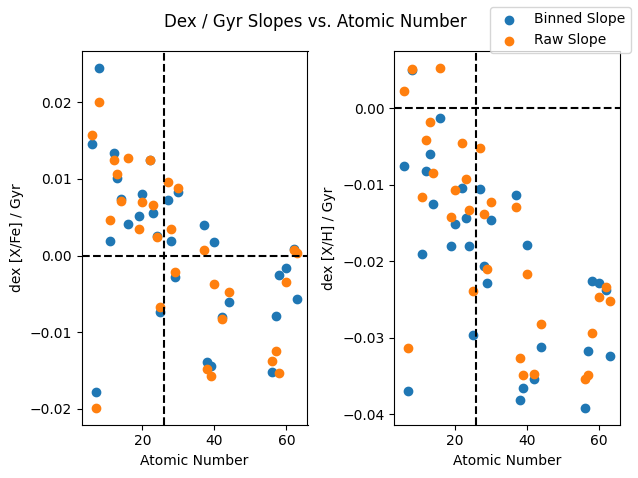

In [26]:
regressionTableDict = {'Element' : [], 'Z' : [], 'b-raw' : [], 'b-binned' : [], 'm-raw' : [], 'm-binned' : [], 'p-value-raw' : [], 'p-value-binned' : [], 'R^2-raw' : [], 'R^2-binned' : []}
for line in lineData:
    line.CalculateRawLinearRegression()
    line.CalculateLinearRegression()
    regressionTableDict['Element'].append(line.label)
    regressionTableDict['Z'].append(line.cfield)
    regressionTableDict['b-raw'].append(line.rawModelResult.params[0])
    regressionTableDict['b-binned'].append(line.binnedModelResult.params[0])
    regressionTableDict['m-raw'].append(line.rawModelResult.params[1])
    regressionTableDict['m-binned'].append(line.binnedModelResult.params[1])
    regressionTableDict['p-value-raw'].append(line.rawModelResult.pvalues[1])
    regressionTableDict['p-value-binned'].append(line.binnedModelResult.pvalues[1])
    regressionTableDict['R^2-raw'].append(line.rawModelResult.rsquared)
    regressionTableDict['R^2-binned'].append(line.binnedModelResult.rsquared)

regressionTableDictOverH = {'Element' : [], 'Z' : [], 'b-raw' : [], 'b-binned' : [], 'm-raw' : [], 'm-binned' : [], 'p-value-raw' : [], 'p-value-binned' : [], 'R^2-raw' : [], 'R^2-binned' : []}
for line in lineDataOverH:
    line.CalculateRawLinearRegression()
    line.CalculateLinearRegression()
    regressionTableDictOverH['Element'].append(line.label)
    regressionTableDictOverH['Z'].append(line.cfield)
    regressionTableDictOverH['b-raw'].append(line.rawModelResult.params[0])
    regressionTableDictOverH['b-binned'].append(line.binnedModelResult.params[0])
    regressionTableDictOverH['m-raw'].append(line.rawModelResult.params[1])
    regressionTableDictOverH['m-binned'].append(line.binnedModelResult.params[1])
    regressionTableDictOverH['p-value-raw'].append(line.rawModelResult.pvalues[1])
    regressionTableDictOverH['p-value-binned'].append(line.binnedModelResult.pvalues[1])
    regressionTableDictOverH['R^2-raw'].append(line.rawModelResult.rsquared)
    regressionTableDictOverH['R^2-binned'].append(line.binnedModelResult.rsquared)

fig, (ax1, ax2) = plt.subplots(ncols=2)
ax1.scatter(regressionTableDict['Z'], regressionTableDict['m-binned'], label='Binned Slope')
ax1.scatter(regressionTableDict['Z'], regressionTableDict['m-raw'], label='Raw Slope')

ax2.scatter(regressionTableDictOverH['Z'], regressionTableDictOverH['m-binned'], label='_Binned Slope')
ax2.scatter(regressionTableDictOverH['Z'], regressionTableDictOverH['m-raw'], label='_Raw Slope')


ax1.set_xlabel('Atomic Number')
ax2.set_xlabel('Atomic Number')
ax1.set_ylabel('dex [X/Fe] / Gyr')
ax2.set_ylabel('dex [X/H] / Gyr')

ax1.axvline(26, color='black', linestyle='--')
ax2.axvline(26, color='black', linestyle='--')
ax1.axhline(0, color='black', linestyle='--')
ax2.axhline(0, color='black', linestyle='--')

fig.legend()

fig.suptitle('Dex / Gyr Slopes vs. Atomic Number')
fig.tight_layout()





plt.show()

## Testing StatsModels ## 

In [28]:
#Lets try a  multi-linear model
import statsmodels.api as sm
import pandas
from patsy import dmatrices

def GetMaskedGalah(str):
    return np.where(Galah[f'flag_{str}'][GMask] ==0, Galah[str][GMask], np.nan)

df = pandas.DataFrame(
    {
        'Age' : np.concat((CombinedAge[UnifiedAPOGEEMask], Galah['age'][GMask])),
        'CFe' : np.concat((cleanData['C_FE'][UnifiedAPOGEEMask], GetMaskedGalah('c_fe'))),
        'NFe' : np.concat((cleanData['N_FE'][UnifiedAPOGEEMask], GetMaskedGalah('n_fe'))),
        'MgFe' : np.concat((cleanData['Mg_FE'][UnifiedAPOGEEMask], GetMaskedGalah('mg_fe'))),
        'TiFe' : np.concat((cleanData['TI_Fe'][UnifiedAPOGEEMask], GetMaskedGalah('ti_fe'))),
        'OFe' : np.concat((cleanData['O_FE'][UnifiedAPOGEEMask], GetMaskedGalah('o_fe'))),
        'MnFe' : np.concat((cleanData['Mn_FE'][UnifiedAPOGEEMask], GetMaskedGalah('mn_fe'))),
        'SiFe' : np.concat((cleanData['Si_Fe'][UnifiedAPOGEEMask], GetMaskedGalah('si_fe'))),
        'AlFe' : np.concat((cleanData['Al_FE'][UnifiedAPOGEEMask], GetMaskedGalah('al_fe'))),
        #'YFe' : np.concat((np.full((UnifiedAPOGEEMask.sum()), np.nan), GetMaskedGalah('y_fe'))),
        #'SFe' : np.concat((cleanData['S_FE'][UnifiedAPOGEEMask], np.full((GMask.sum()), np.nan))),
        #'BaFe' : np.concat((np.full((UnifiedAPOGEEMask.sum()), np.nan), GetMaskedGalah('ba_fe'))),
        'CaFe' : np.concat((cleanData['CA_FE'][UnifiedAPOGEEMask], GetMaskedGalah('Ca_fe'))),
        'CeFe' : np.concat((cleanData['Ce_FE'][UnifiedAPOGEEMask], GetMaskedGalah('Ce_fe'))),
        'NiFe' : np.concat((cleanData['Ni_FE'][UnifiedAPOGEEMask], GetMaskedGalah('Ni_fe'))),
        #'KFe' : np.concat((cleanData['K_FE'][UnifiedAPOGEEMask], GetMaskedGalah('K_fe'))),
    }
)
print(len(df))
#df = df.dropna()
print(len(df))


from itertools import chain, combinations

def powerset(iterable):
    "powerset([1,2,3]) --> () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(1, len(s)+1)))



y, X = dmatrices('Age ~ CFe + NFe + MgFe + OFe + MnFe + AlFe + TiFe + SiFe + CaFe + CeFe + NiFe', data=df, return_type='dataframe')

mod = sm.OLS(y,X, missing='drop')

res = mod.fit()

print(res.summary())

969075
969075
                            OLS Regression Results                            
Dep. Variable:                    Age   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                 4.291e+04
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:41:43   Log-Likelihood:            -6.8341e+05
No. Observations:              340685   AIC:                         1.367e+06
Df Residuals:                  340673   BIC:                         1.367e+06
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4101      0.008    70

In [29]:
dfOverH = df
for col in dfOverH.columns:
    dfOverH[col] = dfOverH[col].add(np.concat((cleanData['Fe_h'][UnifiedAPOGEEMask], GetMaskedGalah('fe_h'))))

# Despite names, these are now XH
y, X = dmatrices('Age ~ CFe + NFe + MgFe + OFe + MnFe + AlFe + TiFe + SiFe + CaFe + CeFe + NiFe', data=df, return_type='dataframe')

mod = sm.OLS(y,X, missing='drop')

res = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                    Age   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                 3.974e+04
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:41:46   Log-Likelihood:            -6.8759e+05
No. Observations:              340667   AIC:                         1.375e+06
Df Residuals:                  340655   BIC:                         1.375e+06
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7325      0.007    791.760      0.0

In [ ]:
for result in results: 
    print(f"elems:{result.params}, rsquared:{result.rsquared}")


elems:Intercept     6.286457
CFe          10.603209
dtype: float64, rsquared:0.21802083438945363
elems:Intercept    6.272768
NFe         -0.802666
dtype: float64, rsquared:0.005740154284852861
elems:Intercept    5.273406
MgFe         9.592012
dtype: float64, rsquared:0.11741383473352418
elems:Intercept    5.503665
OFe          4.305670
dtype: float64, rsquared:0.08535732952675812
elems:Intercept    5.926522
MnFe        -5.936179
dtype: float64, rsquared:0.036103065453718886
elems:Intercept    5.769893
AlFe         4.812621
dtype: float64, rsquared:0.05866703774686133
elems:Intercept    5.797435
TiFe         7.063651
dtype: float64, rsquared:0.07858550739960557
elems:Intercept    5.337635
SiFe         9.393507
dtype: float64, rsquared:0.07209554811523922
elems:Intercept     6.236967
CFe          10.838497
NFe           0.073772
dtype: float64, rsquared:0.20057538035883538
elems:Intercept    5.849846
CFe          8.970873
MgFe         4.832993
dtype: float64, rsquared:0.2433656574319022


## True 3D plots (might be unstable)

In [26]:
a = np.array([['x1','y1','z1'], ['x2','y2','z2'], ['x3','y3','z3']])
print(a.flatten())

['x1' 'y1' 'z1' 'x2' 'y2' 'z2' 'x3' 'y3' 'z3']


In [ ]:
import plotly.graph_objects as go
import plotly.express as px

frame = pandas.DataFrame({'X' : np.concat((AStarPositionXYZ[0][UnifiedAPOGEEMask], GStarPositionXYZ[0])), 
                          'Y' : np.concat((AStarPositionXYZ[1][UnifiedAPOGEEMask], GStarPositionXYZ[1])), 
                          'Z' : np.concat((AStarPositionXYZ[2][UnifiedAPOGEEMask], GStarPositionXYZ[2]))
                          })
points = np.column_stack((np.array(frame.X),np.array(frame.Y),np.array(frame.Z) ))
Histogram3D, edges = np.histogramdd(points, 100, range=((-20,20),(-20,20),(-20,20)))
print(Histogram3D.flatten())

xvalues = (edges[0][1:] + edges[0][:-1]) / 2
yvalues = (edges[1][1:] + edges[1][:-1]) / 2
zvalues = (edges[2][1:] + edges[2][:-1]) / 2

df = pandas.DataFrame(
    {
        'X': xvalues,
        'Y' : yvalues,
        'Z' : zvalues,
        'count' : Histogram3D.flatten()
    }
)

fig = px.scatter_3d(df, x='year', y='continent', z='pop', size='gdpPercap', color='lifeExp',
                    hover_data=['country'])
fig.update_layout(scene_zaxis_type="log")
fig.show()

[0. 0. 0. ... 0. 0. 0.]


ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['X', 'Y', 'Z', 'count'] but received: year

C:\Users\Joshu\AppData\Local\Temp\ipykernel_131268\2933082444.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


np.float64(-inf)

In [35]:
#Orbit Gaussian Version

import pyvista as pv

pv.set_jupyter_backend('html')

frame = pandas.DataFrame({'X' : np.concat((AStarPositionXYZ[0][UnifiedAPOGEEMask], GStarPositionXYZ[0][GMask])), 
                          'Y' : np.concat((AStarPositionXYZ[1][UnifiedAPOGEEMask], GStarPositionXYZ[1][GMask])), 
                          'Z' : np.concat((AStarPositionXYZ[2][UnifiedAPOGEEMask], GStarPositionXYZ[2][GMask])),
                          'CFe' : np.concat((cleanData['C_FE'][UnifiedAPOGEEMask], Galah['c_fe'][GMask]))
                          })
points = np.column_stack((np.array(frame.X),np.array(frame.Y),np.array(frame.Z) ))
Histogram3D, edges = np.histogramdd(points, 100, range=((-20,20),(-20,20),(-20,20)))


xvalues = (edges[0][1:] + edges[0][:-1]) / 2
yvalues = (edges[1][1:] + edges[1][:-1]) / 2
zvalues = (edges[2][1:] + edges[2][:-1]) / 2

values = []

for x in range(100):
    for y in range(100):
        for z in range(100):
            values.append([xvalues[x], yvalues[y], zvalues[z]])

Histogram3D = np.log(Histogram3D,)
Histogram3D = np.where(np.isfinite(Histogram3D), Histogram3D, 0)

pl = pv.Plotter()
pl.add_points(np.array(values), 
              style='points_gaussian',
              scalars=Histogram3D.flatten(),
              opacity=[0,0.1,0.3,0.35,0.5],
              point_size=5,
              cmap='rainbow',
              scalar_bar_args= dict(color='w'),
              emissive=False
              )

pl.show_grid(color='w')

pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)

pl.camera.zoom(1.65)
pl.background_color = 'k'
pl.show(auto_close=False)
path = pl.generate_orbital_path(n_points=72, shift=5, factor=1, viewup=[0,0,1])
path2 = pl.generate_orbital_path(n_points=72, shift=5, factor=1, viewup=[1,0,0])
pl.open_gif('Histogram3D2.gif')
pl.orbit_on_path(path2, write_frames=True)




C:\Users\Joshu\AppData\Local\Temp\ipykernel_141776\3333781752.py:27: RuntimeWarning: divide by zero encountered in log
  Histogram3D = np.log(Histogram3D,)
C:\Users\Joshu\AppData\Local\Temp\ipykernel_141776\3333781752.py:43: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_141776/3333781752.py:43: Arguments 'radius', 'center' must be passed as keyword arguments to function 'Sphere'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
C:\Users\Joshu\AppData\Local\Temp\ipykernel_141776\3333781752.py:44: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_141776/3333781752.py:44: Argument 'radius' must be passed as a keyword argument to function 'Circle'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [16]:
#Orbit Age Gaussian Version

import pyvista as pv

pv.set_jupyter_backend('html')

frame = pandas.DataFrame({'X' : np.concat((AStarPositionXYZ[0][UnifiedAPOGEEMask], GStarPositionXYZ[0][GMask])), 
                          'Y' : np.concat((AStarPositionXYZ[1][UnifiedAPOGEEMask], GStarPositionXYZ[1][GMask])), 
                          'Z' : np.concat((AStarPositionXYZ[2][UnifiedAPOGEEMask], GStarPositionXYZ[2][GMask])),
                          'Age' : np.concat((CombinedAge[UnifiedAPOGEEMask], Galah['age'][GMask])),
                          'CFe' : np.concat((cleanData['C_FE'][UnifiedAPOGEEMask], Galah['c_fe'][GMask]))
                          })

binEdges = np.histogram_bin_edges(frame['X'], bins=100, range=(-20,20))
frame = frame.assign(
    XBin=pandas.cut(frame.X, binEdges, labels=(binEdges[1:] + binEdges[:-1]) / 2),
    YBin = pandas.cut(frame.Y, binEdges,labels=(binEdges[1:] + binEdges[:-1]) / 2),
    ZBin= pandas.cut(frame.Z, binEdges,labels=(binEdges[1:] + binEdges[:-1]) / 2)
)
frame = frame.assign(cartesian=pandas.Categorical(frame.filter(regex='Bin').apply(tuple, 1)))
print(frame)


                X         Y         Z        Age       CFe  XBin YBin ZBin  \
0       -8.456299  0.683176 -0.039063   1.033130  0.112730  -8.6  0.6 -0.2   
1       -8.456299  0.683176 -0.039063   1.375945  0.032651  -8.6  0.6 -0.2   
2       -8.435739  0.643640 -0.041066   6.705514 -0.025731  -8.6  0.6 -0.2   
3      -11.880131  7.304677  0.197082   1.957528 -0.180636 -11.8  7.4  0.2   
4       -9.024924  1.864135 -0.184874   2.314873 -0.011290  -9.0  1.8 -0.2   
...           ...       ...       ...        ...       ...   ...  ...  ...   
969070  -7.985268 -0.130209 -0.293419   7.916256  0.102779  -7.8 -0.2 -0.2   
969071  -7.907314 -0.190796 -0.503658   8.834783  0.137229  -7.8 -0.2 -0.6   
969072  -7.835185 -0.314584 -0.544424   9.151339  0.010558  -7.8 -0.2 -0.6   
969073  -7.940447 -0.154505 -0.438329  13.606515  0.100784  -7.8 -0.2 -0.6   
969074  -8.122544  0.004941  0.012125   4.473416  0.014838  -8.2  0.2  0.2   

                                                cartesian  
0  

In [ ]:

typedFrame = frame
typedFrame['XBin'] = pandas.to_numeric(typedFrame['XBin'])
typedFrame['YBin'] = pandas.to_numeric(typedFrame['YBin'])
typedFrame['ZBin'] = pandas.to_numeric(typedFrame['ZBin'])
finalFrame = typedFrame.groupby(['cartesian']).mean()
#print(finalFrame)
points = []
ages = []
CFe = []
for (X,Y,Z,Age,XBin,YBin,ZBin,CFeVal) in zip(finalFrame.X,finalFrame.Y,finalFrame.Z,finalFrame.Age,finalFrame.XBin,finalFrame.YBin,finalFrame.ZBin, finalFrame.CFe):
    if Age is np.nan or XBin is np.nan or YBin is np.nan or ZBin is np.nan or CFe is np.nan:
        continue
    points.append([XBin, YBin, ZBin])
    ages.append(Age)
    CFe.append(CFeVal)

-0.0900482580065727


In [43]:
pl = pv.Plotter()
pl.add_points(np.array(points), 
              style='points_gaussian',
              scalars=ages,
              opacity=[0,0.1,0.3,0.35,0.5],
              point_size=4,
              cmap='Spectral',
              clim=[np.nanpercentile(ages,2), np.nanpercentile(ages,98)],
              scalar_bar_args= dict(color='w', title='[C/Fe]'),
              emissive=False
              )

pl.show_grid(color='w')

pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)

pl.background_color = 'k'
pl.show(auto_close=False)
path2 = pl.generate_orbital_path(n_points=72*2, shift=5, factor=1, viewup=[1,0,0])
pl.open_gif('3DMaps/AgeProperColors3D.gif')
pl.orbit_on_path(path2, write_frames=True)
pl.close()

C:\Users\Joshu\AppData\Local\Temp\ipykernel_136004\3057681075.py:15: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_136004/3057681075.py:15: Arguments 'radius', 'center' must be passed as keyword arguments to function 'Sphere'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
C:\Users\Joshu\AppData\Local\Temp\ipykernel_136004\3057681075.py:16: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_136004/3057681075.py:16: Argument 'radius' must be passed as a keyword argument to function 'Circle'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [71]:


pl = pv.Plotter()
pl.add_points(np.array(points), 
              style='points_gaussian',
              scalars=ages,
              opacity=[0,0.1,0.3,0.35,0.5],
              point_size=5,
              cmap='rainbow',
              scalar_bar_args= dict(color='w', title='Age [Gyr]'),
              emissive=False
              )

pl.show_grid(color='w')

pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)

pl.camera.zoom(1.75)
pl.background_color = 'k'
pl.show(auto_close=False)
path2 = pl.generate_orbital_path(n_points=72*2, shift=5, factor=1, viewup=[1,0,0])
pl.open_gif('3DMaps/Age3D.gif')
pl.orbit_on_path(path2, write_frames=True)
pl.close()
"""pl.show(auto_close=False)
pl.open_gif('Age3D2.gif')
pl.orbit_on_path(path, write_frames=True)
pl.close()
"""


C:\Users\Joshu\AppData\Local\Temp\ipykernel_145200\1694008.py:14: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_145200/1694008.py:14: Arguments 'radius', 'center' must be passed as keyword arguments to function 'Sphere'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
C:\Users\Joshu\AppData\Local\Temp\ipykernel_145200\1694008.py:15: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_145200/1694008.py:15: Argument 'radius' must be passed as a keyword argument to function 'Circle'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

"pl.show(auto_close=False)\npl.open_gif('Age3D2.gif')\npl.orbit_on_path(path, write_frames=True)\npl.close()\n"

In [15]:
#View Mode Version

import pyvista as pv

pv.set_jupyter_backend('html')

frame = pandas.DataFrame({'X' : np.concat((AStarPositionXYZ[0][UnifiedAPOGEEMask], GStarPositionXYZ[0][GMask])), 
                          'Y' : np.concat((AStarPositionXYZ[1][UnifiedAPOGEEMask], GStarPositionXYZ[1][GMask])), 
                          'Z' : np.concat((AStarPositionXYZ[2][UnifiedAPOGEEMask], GStarPositionXYZ[2][GMask])),
                          'CFe' : np.concat((cleanData['C_FE'][UnifiedAPOGEEMask], Galah['c_fe'][GMask]))
                          })
points = np.column_stack((np.array(frame.X),np.array(frame.Y),np.array(frame.Z) ))
Histogram3D, edges = np.histogramdd(points, 100, range=((-20,20),(-20,20),(-20,20)))


xvalues = (edges[0][1:] + edges[0][:-1]) / 2
yvalues = (edges[1][1:] + edges[1][:-1]) / 2
zvalues = (edges[2][1:] + edges[2][:-1]) / 2

values = []

for x in range(100):
    for y in range(100):
        for z in range(100):
            values.append([xvalues[x], yvalues[y], zvalues[z]])

Histogram3D = np.log(Histogram3D,)
Histogram3D = np.where(np.isfinite(Histogram3D), Histogram3D, 0)

pl = pv.Plotter()
pl.add_points(np.array(values), 
              style='points',
              render_points_as_spheres=True,
              scalars=Histogram3D.flatten(),
              opacity=[0,0.1,0.3,0.35,0.5],
              point_size=5,
              cmap='rainbow',
              scalar_bar_args= dict(color='w'),
              emissive=False
              )

pl.show_grid(color='w')

pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)

pl.camera.zoom(1.5)
pl.background_color = 'k'
pl.show()


C:\Users\Joshu\AppData\Local\Temp\ipykernel_141776\3730437420.py:27: RuntimeWarning: divide by zero encountered in log
  Histogram3D = np.log(Histogram3D,)
C:\Users\Joshu\AppData\Local\Temp\ipykernel_141776\3730437420.py:44: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_141776/3730437420.py:44: Arguments 'radius', 'center' must be passed as keyword arguments to function 'Sphere'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  pl.add_mesh(pv.Sphere(0.5, (0,0,0)), color='black')
C:\Users\Joshu\AppData\Local\Temp\ipykernel_141776\3730437420.py:45: PyVistaDeprecationWarning: 
../../../../../AppData/Local/Temp/ipykernel_141776/3730437420.py:45: Argument 'radius' must be passed as a keyword argument to function 'Circle'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  pl.add_mesh(pv.Circle(25), color='purple', opacity=0.5)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…